# 손 X-ray 골연령 — **ConvNeXt-Tiny 단일 회귀 · v2**
### 비정사각 640×448 · 이미지별 강도 정규화 · 코사인 완주 · TTA + 캘리브레이션

v1(`레터박스512_1`, 전처리 없음)의 결과 **val 5.94 / test 4.53 [4.07, 5.01]** 을 기준선으로,
아래 5가지를 반영한 개선판입니다. **v1은 대조군으로 건드리지 않습니다.**

## v1 → v2 변경점

| # | 항목 | v1 | v2 | 근거 |
|---|---|---|---|---|
| 1 | `EPOCHS` / 조기종료 | 100 / patience 12 | **40 / 끔** | v1은 29에폭에 끊겨 **LR이 피크의 84%인 채로 종료**. 코사인을 완주시킴 |
| 2 | 입력 캔버스 | 512×512 정사각 | **640×448 (H×W)** | v1 여백 중앙 **30.1%**. 손 종횡비 ≈0.65에 맞춰 여백을 한 자릿수로 |
| 3 | 화소 처리 | 없음 | **이미지별 퍼센타일(1–99) 정규화** | v1 QC에서 원본 std가 **6.9 ~ 55.6 (8배 편차)**. 고정 ImageNet 정규화로는 보정 불가 |
| 4 | 증강 / 정칙화 | Affine only, drop_path 0.05 | **+ ColorJitter · shear · RandomErasing**, drop_path **0.15** | 노출 편차 모사 + 약한 과적합(train 5.26 vs val 6.66) 억제 |
| 5 | 추론 | 단일 forward | **회전 TTA(0, ±4°) + val 기반 선형 캘리브레이션** | 연령대별 bias +3.65(0-4y) ~ −2.71(>16y) = 회귀 축소 |

> **주의 — 이 노트북은 더 이상 "전처리 없음" 실험이 아닙니다.**
> 3번(퍼센타일 정규화) 때문에 v10 무전처리 대조군과 직접 비교할 수 없습니다.
> 2×2 ablation 표의 "전처리 없음 × 단일 회귀" 칸에는 **v1 수치**를 쓰세요.

## 저장 경로 (v1과 완전 분리)

```
캐시       BASE_DIR / cache_convnext_single_v2 / <PRE_TAG>
체크포인트  BASE_DIR / checkpoints_convnext_single_v2
```

## 백본 — 상업 사용 가능한 ConvNeXt V1만

| 모델 | 계열 | 라이선스 | 상업 |
|---|---|---|---|
| **`convnext_tiny.fb_in22k_ft_in1k_384`** ← 기본값 | V1 | Apache-2.0 / MIT | 가능 |
| `convnext_tiny.fb_in22k_ft_in1k` | V1 | Apache-2.0 / MIT | 가능 |
| `convnext_tiny.in12k_ft_in1k` | V1 (timm 자체) | Apache-2.0 | 가능 |
| ~~`convnextv2_*`~~ | V2 | **CC BY-NC 4.0** | **불가** |

## 실행 순서
`PART 0` → `PART 1`(캐시, **v1 캐시 재사용 불가 — 새로 생성됨**) → `PART 2` → `PART 3`(학습) → `PART 4`(평가)
`PART 4`는 `best.pt`만 있으면 단독 실행됩니다.

---
# PART 0 · 공통 셋업  *(전부 정의/로드 — 무거운 연산 없음)*

### 0-1. 환경 확인

In [1]:
import os, sys, json, math, random, time, copy
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm

# !pip install timm            # 최초 1회만
import timm

print("Python     :", sys.version.split()[0])
print("PyTorch    :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("timm       :", timm.__version__)
print("OpenCV     :", cv2.__version__)
print("CUDA avail :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0), "| CUDA", torch.version.cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     :", device)

# RTX 5060(Blackwell, sm_120)에서 CUDA=False 또는 'no kernel image' 오류가 나면:
#   pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

Python     : 3.11.9
PyTorch    : 2.12.0.dev20260408+cu128
torchvision: 0.27.0.dev20260407+cu128
timm       : 1.0.28
OpenCV     : 4.10.0
CUDA avail : True
GPU        : NVIDIA GeForce RTX 5060 Laptop GPU | CUDA 12.8
device     : cuda


### 0-2. 시드 & 한글 경로 로더
`cv2.imread/imwrite`는 경로에 한글이 있으면 **조용히 실패**합니다 → `np.fromfile + imdecode` 조합을 씁니다.

In [2]:
SEED = 42                      # 시드 앙상블을 돌릴 때 42 / 1337 / 2024 로 바꾸세요
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


def imread_kr(path, flags=cv2.IMREAD_GRAYSCALE):
    '''한글/유니코드 경로에서도 동작하는 이미지 로드. 실패 시 None.'''
    try:
        return cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), flags)
    except Exception:
        return None


def imwrite_kr(path, img):
    '''한글/유니코드 경로에도 저장 가능한 이미지 쓰기.'''
    path = str(path); ext = os.path.splitext(path)[1] or ".png"
    try:
        ok, buf = cv2.imencode(ext, img)
        if ok:
            buf.tofile(path)
        return ok
    except Exception:
        return False


def torch_load(path, map_location=None):
    '''PyTorch 2.6+ 는 weights_only 기본값이 True -> arch 딕셔너리 로드가 막힙니다.'''
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def require(path, what):
    '''경로가 없으면 즉시 중단. 잘못된 경로로 조용히 진행하지 않습니다.'''
    p = Path(path)
    assert p.exists(), f"[중단] {what} 경로가 없습니다: {p}"
    return p

print("헬퍼 정의 완료 · SEED =", SEED)

헬퍼 정의 완료 · SEED = 42


### 0-3. 경로 & 이미지 준비 설정 ★ v2 변경 핵심

**`BASE_DIR` 한 줄만** 본인 환경에 맞게 수정하세요.
캐시/체크포인트는 `_v2` 접미사로 v1·v8·v10과 **완전히 분리**됩니다.

| 설정 | v1 | v2 |
|---|---|---|
| 캔버스 | 512 × 512 | **640 × 448** (H × W) |
| 화소 정규화 | 없음 | **`p1p99`** (이미지별 퍼센타일 스트레치) |
| 캐시 | `cache_convnext_single_1(1)` | **`cache_convnext_single_v2`** |
| 체크포인트 | `checkpoints_convnext_single_1(1)` | **`checkpoints_convnext_single_v2`** |

In [3]:
# ── 경로: 여기만 수정 ───────────────────────────────────────────────
BASE_DIR      = Path(r"C:\Users\Win11Pro\Desktop")
HAND_CROP_DIR = BASE_DIR / "crop_data_final"        # training / validation / test 하위폴더
CSV_DIR       = BASE_DIR / "crop_data_final"        # training.csv / validation.csv / test.csv

SPLIT_SUBDIR = {"train": "training", "val": "validation", "test": "test"}

TRAIN_CSV = require(CSV_DIR / "training.csv",   "training.csv")
VAL_CSV   = require(CSV_DIR / "validation.csv", "validation.csv")
TEST_CSV  = require(CSV_DIR / "test.csv",       "test.csv")
require(HAND_CROP_DIR, "손 크롭 폴더")

# ══ 이미지 준비 ═══════════════════════════════════════════════════
# [v2] 비정사각 캔버스. RSNA 손 크롭 종횡비(w/h) 중앙값 ≈ 0.65 → 448/640 = 0.70
#      v1의 512x512 대비 픽셀 수 +9%, 여백은 30% → 8~12% 로 감소
IMG_H, IMG_W = 640, 448
IMG_SIZE     = (IMG_H, IMG_W)      # 하위 호환용 튜플

RESIZE_MODE = "letterbox"  # "letterbox"(비율유지+패딩, 권장) | "stretch"(강제 리사이즈)
PAD_VALUE   = 0            # 패딩 상수
PAD_ANCHOR  = "center"     # "center" | "topleft"

# [v2][추론] 이미지별 강도 정규화. "none" 이면 v1과 동일한 무전처리
NORM_MODE   = "p1p99"      # "none" | "p1p99" | "p2p98"

# 설정이 다르면 캐시 폴더가 자동으로 분리됩니다
PRE_TAG   = f"raw{IMG_H}x{IMG_W}_{RESIZE_MODE}_pad{PAD_VALUE}_{PAD_ANCHOR}_n{NORM_MODE}"
CACHE_DIR = BASE_DIR / "cache_convnext_single_v2" / PRE_TAG        # ★ v2 전용
CKPT_DIR  = BASE_DIR / "checkpoints_convnext_single_v2"            # ★ v2 전용
for sp in SPLIT_SUBDIR:
    (CACHE_DIR / sp).mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PRE_DONE     = CACHE_DIR / "_DONE.json"
BEST_CKPT    = CKPT_DIR / "best.pt"
LAST_CKPT    = CKPT_DIR / "last.pt"
HISTORY_JSON = CKPT_DIR / "history.json"
RESULTS_JSON = CKPT_DIR / "results.json"

# v1 결과 파일 (있으면 PART 4에서 자동 비교)
V1_RESULTS   = BASE_DIR / "checkpoints_convnext_single_1(1)" / "results.json"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
# 정규화 공간에서 '픽셀값 0'에 해당하는 값 → 회전 TTA/증강의 여백 채우기에 사용
PAD_NORM = [-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)]

print(f"캐시       {CACHE_DIR}")
print(f"체크포인트 {CKPT_DIR}")
print(f"이미지 준비: {RESIZE_MODE} -> {IMG_H}x{IMG_W} (HxW) | pad {PAD_VALUE} | norm {NORM_MODE}")
print(f"정규화 여백값 {['%.3f' % v for v in PAD_NORM]}")
assert "checkpoints_convnext_single_v2" in str(CKPT_DIR), "[중단] v1 경로를 덮어쓰려 합니다."

캐시       C:\Users\Win11Pro\Desktop\cache_convnext_single_v2\raw640x448_letterbox_pad0_center_np1p99
체크포인트 C:\Users\Win11Pro\Desktop\checkpoints_convnext_single_v2
이미지 준비: letterbox -> 640x448 (HxW) | pad 0 | norm p1p99
정규화 여백값 ['-2.118', '-2.036', '-1.804']


### 0-4. 제외 ID
`USE_EXCLUDE=True`는 v8/v10과 **같은 조건**으로 비교하기 위한 설정입니다.
test에 필터를 적용하면 낙관적 편향이 생기므로, PART 4에서 **필터/비필터 두 수치를 모두** 출력합니다.
(v1 실행 시점에는 목록이 비어 있어 두 수치가 동일했습니다.)

In [4]:
USE_EXCLUDE = True   # v8/v10 과 동일 조건으로 맞추려면 True

EXCLUDE_IDS = set() if USE_EXCLUDE else set()   # 필요 시 여기에 id 문자열을 채우세요

print(f"제외 ID {len(EXCLUDE_IDS)}개 · USE_EXCLUDE={USE_EXCLUDE}")
if USE_EXCLUDE and not EXCLUDE_IDS:
    print("  [알림] 목록이 비어 있어 필터/비필터 수치가 동일하게 나옵니다.")

제외 ID 0개 · USE_EXCLUDE=True
  [알림] 목록이 비어 있어 필터/비필터 수치가 동일하게 나옵니다.


### 0-5. 라벨 로드 & 파일 인덱싱

In [5]:
def load_labels(csv_path):
    '''id/boneage/male 컬럼을 유연하게 탐지해 표준 DataFrame으로 반환.'''
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}

    def pick(keys):
        for k in keys:
            for lc, orig in cols.items():
                if k in lc:
                    return orig
        return None

    id_col  = pick(["id", "case", "image"]) or df.columns[0]
    age_col = pick(["boneage", "bone age", "age"])
    sex_col = pick(["male", "sex", "gender"])
    assert age_col and sex_col, f"컬럼 탐지 실패: {list(df.columns)}"

    out = pd.DataFrame()
    out["id"]      = df[id_col].astype(str).str.replace(".png", "", regex=False).str.strip()
    out["boneage"] = pd.to_numeric(df[age_col], errors="coerce")
    s = df[sex_col]
    if s.dtype == bool:
        male = s.astype(int)
    else:
        sv = s.astype(str).str.lower().str.strip()
        male = sv.map({"true": 1, "false": 0, "m": 1, "f": 0,
                       "male": 1, "female": 0, "1": 1, "0": 0})
        if male.isna().any():
            male = pd.to_numeric(s, errors="coerce")
    out["male"] = male.astype(float)
    return out.dropna(subset=["boneage", "male"]).reset_index(drop=True)


def index_files(split):
    '''{id(stem): 파일경로} 인덱스. 하위 폴더까지 재귀 탐색.'''
    d = HAND_CROP_DIR / SPLIT_SUBDIR[split]
    assert d.exists(), f"[중단] {split} 이미지 폴더 없음: {d}"
    idx = {}
    for ext in ("*.png", "*.PNG", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
        for p in d.rglob(ext):
            idx.setdefault(p.stem.strip(), p)
    return idx


SPLIT_DFS, FILE_INDEX = {}, {}
for sp, csv in [("train", TRAIN_CSV), ("val", VAL_CSV), ("test", TEST_CSV)]:
    df  = load_labels(csv)
    idx = index_files(sp)
    FILE_INDEX[sp] = idx
    before = len(df)
    if EXCLUDE_IDS:
        df = df[~df["id"].isin(EXCLUDE_IDS)]
    df = df[df["id"].isin(idx.keys())].reset_index(drop=True)
    df["path"] = df["id"].map(lambda i: str(idx[i]))
    SPLIT_DFS[sp] = df
    print(f"  {sp:<5} 라벨 {before:>6,} -> 사용 {len(df):>6,}  (제외/미크롭 {before-len(df):,})")

train_df, val_df, test_df = SPLIT_DFS["train"], SPLIT_DFS["val"], SPLIT_DFS["test"]
assert len(train_df) > 0, "[중단] train 사용 가능 이미지가 0장입니다."

# 타깃 z-정규화 상수는 반드시 train 에서만 (val/test 누수 방지)
AGE_MEAN = float(train_df["boneage"].mean())
AGE_STD  = float(train_df["boneage"].std())
print(f"\n타깃 정규화 (train 기준): {AGE_MEAN:.2f} ± {AGE_STD:.2f} 개월")
print(f"남아 비율 {train_df.male.mean():.1%} | 연령 범위 "
      f"{train_df.boneage.min():.0f}~{train_df.boneage.max():.0f} 개월")

  train 라벨 12,441 -> 사용 12,441  (제외/미크롭 0)
  val   라벨  1,399 -> 사용  1,399  (제외/미크롭 0)
  test  라벨    197 -> 사용    197  (제외/미크롭 0)

타깃 정규화 (train 기준): 127.48 ± 40.94 개월
남아 비율 54.2% | 연령 범위 1~228 개월


### 0-6. 이미지 준비 함수 ★ v2 변경

| 함수 | 하는 일 | v1 대비 |
|---|---|---|
| `to_gray8` | 16bit/float 입력만 8bit로 낮춤 | 동일 |
| `norm_intensity` | **이미지별 퍼센타일 스트레치** (배경 0 제외) | **신규** |
| `fit_canvas` | 비율유지 리사이즈 + 패딩 | **정사각 → 비정사각** |

`norm_intensity`는 **패딩 전, 원본 크롭 위에서** 수행합니다.
letterbox 이후에 하면 패딩 0이 통계에 섞여 스트레치가 망가집니다.

In [6]:
def to_gray8(g):
    '''16bit·float 입력만 8bit 로 변환. 이미 uint8 이면 무연산 통과.'''
    if g.dtype == np.uint8:
        return g
    g = g.astype(np.float32)
    lo, hi = float(g.min()), float(g.max())
    if hi - lo < 1e-6:
        return np.zeros(g.shape, np.uint8)
    return np.clip((g - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)


def norm_intensity(g, mode=None):
    '''[추론] 논문 미명시. 이미지별 퍼센타일 스트레치.

    v1 QC에서 원본 std가 6.9(id 2821) ~ 55.6(id 14141) 로 8배 차이났습니다.
    고정 ImageNet mean/std 로는 이 편차를 보정할 수 없어 골단선 대비가
    이미지마다 완전히 다른 스케일로 네트워크에 들어갑니다.

    YOLO 크롭의 0-패딩 배경은 통계에서 제외합니다.
    '''
    mode = NORM_MODE if mode is None else mode
    if mode == "none":
        return g
    v = g[g > 0]
    if v.size < 1000:                       # 거의 빈 이미지는 건드리지 않음
        return g
    if mode == "p1p99":
        lo, hi = np.percentile(v, (1, 99))
    elif mode == "p2p98":
        lo, hi = np.percentile(v, (2, 98))
    else:
        raise ValueError(f"알 수 없는 NORM_MODE: {mode}")
    if hi - lo < 1e-3:
        return g
    out = (g.astype(np.float32) - lo) / (hi - lo) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)


def fit_canvas(g, h_out=None, w_out=None, mode=None,
               pad_val=None, anchor=None, norm=None):
    '''h_out x w_out 캔버스로 맞춥니다. 반환 (canvas, info)

    [v2] 정사각 강제를 폐지하고 H/W 를 따로 받습니다.
         스케일은 min(h_out/h, w_out/w) → 양 변 모두 넘치지 않는 최대 배율.
    '''
    h_out  = IMG_H       if h_out  is None else h_out
    w_out  = IMG_W       if w_out  is None else w_out
    mode   = RESIZE_MODE if mode   is None else mode
    pad_val= PAD_VALUE   if pad_val is None else pad_val
    anchor = PAD_ANCHOR  if anchor is None else anchor

    g = to_gray8(g)
    g = norm_intensity(g, NORM_MODE if norm is None else norm)   # ★ 패딩 전에 수행
    h, w = g.shape[:2]

    if mode == "stretch":
        interp = cv2.INTER_AREA if (h_out < h and w_out < w) else cv2.INTER_CUBIC
        out = cv2.resize(g, (w_out, h_out), interpolation=interp)
        return out, {"s": (h_out / h, w_out / w), "src": (h, w),
                     "pad": (0, 0, 0, 0), "pad_frac": 0.0}

    s  = min(h_out / float(h), w_out / float(w))     # 비율 왜곡 0
    nh = max(1, min(h_out, int(round(h * s))))
    nw = max(1, min(w_out, int(round(w * s))))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC
    r = cv2.resize(g, (nw, nh), interpolation=interp)

    top  = 0 if anchor == "topleft" else (h_out - nh) // 2
    left = 0 if anchor == "topleft" else (w_out - nw) // 2
    out = cv2.copyMakeBorder(r, top, h_out - nh - top, left, w_out - nw - left,
                             cv2.BORDER_CONSTANT, value=int(pad_val))
    return out, {"s": s, "src": (h, w),
                 "pad": (top, h_out - nh - top, left, w_out - nw - left),
                 "pad_frac": 1.0 - (nh * nw) / float(h_out * w_out)}

print(f"이미지 준비 함수 정의 완료 | 캔버스 {IMG_H}x{IMG_W} | 강도정규화 {NORM_MODE}")

이미지 준비 함수 정의 완료 | 캔버스 640x448 | 강도정규화 p1p99


---
# PART 1 · 캐시 생성  *(1회만; 완료 표식 있으면 자동 스킵)*

**v1 캐시는 재사용되지 않습니다.** 캔버스 크기와 정규화 모드가 `PRE_TAG`에 들어가
새 폴더가 만들어집니다. 12,611장 기준 수 분 내외.

In [7]:
FORCE_REBUILD = False   # 캐시를 강제로 다시 만들려면 True

PRE_INFO = {"preprocess": NORM_MODE, "img_h": IMG_H, "img_w": IMG_W,
            "resize_mode": RESIZE_MODE, "pad_value": PAD_VALUE,
            "pad_anchor": PAD_ANCHOR,
            "n": {k: len(v) for k, v in SPLIT_DFS.items()}}


def cache_valid():
    if FORCE_REBUILD or not PRE_DONE.exists():
        return False
    try:
        return json.load(open(PRE_DONE, encoding="utf-8")) == PRE_INFO
    except Exception:
        return False


if cache_valid():
    print("캐시 유효 - PART 1 스킵 (다시 만들려면 FORCE_REBUILD=True)")
else:
    pad_fracs = []
    for sp in ("train", "val", "test"):
        df = SPLIT_DFS[sp]
        if not len(df):
            continue
        made = skipped = failed = 0
        for _, r in tqdm(df.iterrows(), total=len(df), desc=f"cache {sp}"):
            dst = CACHE_DIR / sp / f"{r['id']}.png"
            if dst.exists() and not FORCE_REBUILD:
                skipped += 1
                continue
            g = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
            if g is None:
                failed += 1
                continue
            canvas, info = fit_canvas(g)
            imwrite_kr(dst, canvas)
            pad_fracs.append(info["pad_frac"])
            made += 1
        print(f"  [{sp}] 생성 {made:,} · 스킵 {skipped:,} · 실패 {failed:,}")
    if pad_fracs:
        pf = np.array(pad_fracs)
        print(f"\n여백 비율: 중앙 {np.median(pf):.1%} · 90%tile {np.percentile(pf,90):.1%} "
              f"· 최대 {pf.max():.1%}")
        print("  (v1 512x512 기준: 중앙 30.1% · 90%tile 39.5% · 최대 52.9%)")
        if np.median(pf) > 0.20:
            print("  [경고] 여백이 여전히 20%를 넘습니다 -> IMG_H/IMG_W 종횡비를 재검토하세요.")
        else:
            print("  [정상] 여백이 v1 대비 크게 줄었습니다.")
    json.dump(PRE_INFO, open(PRE_DONE, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
    print("\n캐시 완료:", PRE_DONE)

cache train:   0%|          | 0/12441 [00:00<?, ?it/s]

  [train] 생성 12,441 · 스킵 0 · 실패 0


cache val:   0%|          | 0/1399 [00:00<?, ?it/s]

  [val] 생성 1,399 · 스킵 0 · 실패 0


cache test:   0%|          | 0/197 [00:00<?, ?it/s]

  [test] 생성 197 · 스킵 0 · 실패 0

여백 비율: 중앙 9.4% · 90%tile 20.5% · 최대 65.3%
  (v1 512x512 기준: 중앙 30.1% · 90%tile 39.5% · 최대 52.9%)
  [정상] 여백이 v1 대비 크게 줄었습니다.

캐시 완료: C:\Users\Win11Pro\Desktop\cache_convnext_single_v2\raw640x448_letterbox_pad0_center_np1p99\_DONE.json


### (필수) QC — 강도 정규화가 실제로 먹었는지 확인

v1의 QC는 "화소값을 건드리지 않았음"을 증명하는 것이었지만,
v2는 반대로 **"이미지별 편차가 실제로 줄었음"** 을 증명해야 합니다.

- `원본std` 는 이미지마다 6.9~55.6 처럼 크게 흔들립니다.
- `유효std`(패딩 제외 영역)가 **모든 행에서 비슷한 값으로 수렴**해야 정상입니다.
- 아래 요약의 **`유효std 변동계수(CV)`가 원본보다 뚜렷이 작아야** 합니다.

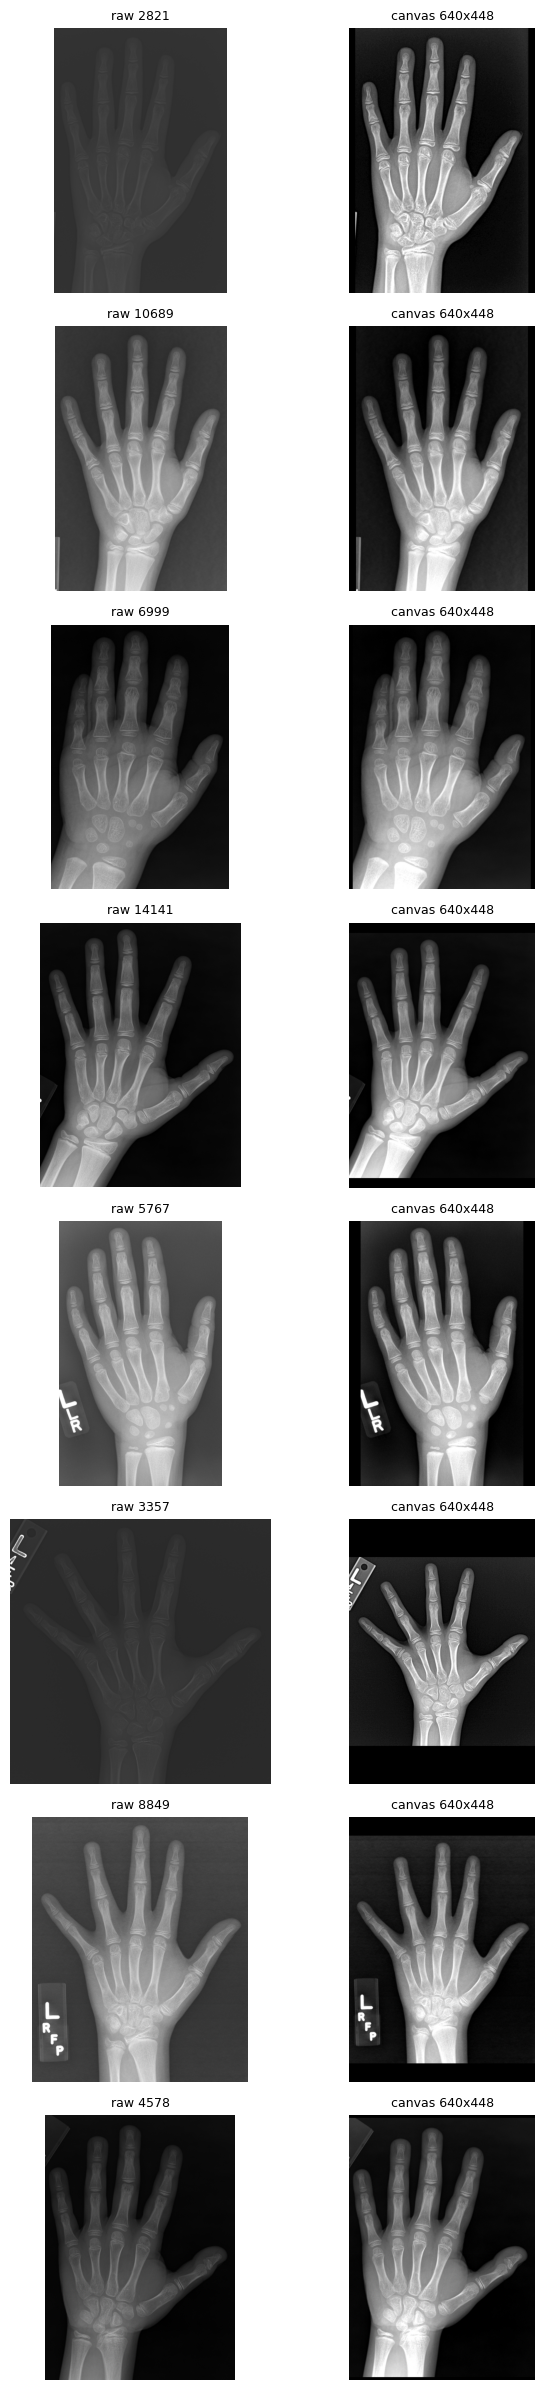

,id,원본크기,원본min~max,원본std,유효std,여백%
0,2821,704x1081,46~83,6.9,75.5,7%
1,10689,1038x1606,38~255,49.0,73.9,8%
2,6999,748x1115,0~214,49.8,74.4,4%
3,14141,1144x1512,0~250,55.6,74.1,7%
4,5767,746x1218,53~255,46.9,74.6,12%
5,3357,987x1004,38~255,10.1,65.7,29%
6,8849,1271x1559,41~255,45.6,71.0,14%
7,4578,959x1339,0~203,37.2,70.3,2%


std 변동계수(CV):  원본 0.497  ->  정규화 후 0.045
  [정상] 이미지 간 대비 편차가 크게 줄었습니다.


In [8]:
N_QC = 8
sample = train_df.sample(min(N_QC, len(train_df)), random_state=SEED)

fig, axes = plt.subplots(len(sample), 2, figsize=(7, 3.0 * len(sample)))
axes = np.atleast_2d(axes)
rows = []
for i, (_, r) in enumerate(sample.iterrows()):
    raw = imread_kr(r["path"], cv2.IMREAD_GRAYSCALE)
    cv_ = imread_kr(CACHE_DIR / "train" / f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    _, info = fit_canvas(raw)
    top, bot, left, right = info["pad"]
    eff = cv_[top:cv_.shape[0] - bot if bot else None,
              left:cv_.shape[1] - right if right else None]
    rows.append({"id": r["id"], "원본크기": f"{raw.shape[1]}x{raw.shape[0]}",
                 "원본min~max": f"{raw.min()}~{raw.max()}",
                 "원본std": round(float(raw.std()), 1),
                 "유효std": round(float(eff.std()), 1),
                 "여백%": f"{info['pad_frac']:.0%}"})
    for ax, (t, im) in zip(axes[i], [(f"raw {r['id']}", raw),
                                     (f"canvas {IMG_H}x{IMG_W}", cv_)]):
        ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(t, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

qc = pd.DataFrame(rows)
display(qc)

cv_raw = qc["원본std"].std() / qc["원본std"].mean()
cv_eff = qc["유효std"].std() / qc["유효std"].mean()
print(f"std 변동계수(CV):  원본 {cv_raw:.3f}  ->  정규화 후 {cv_eff:.3f}")
if NORM_MODE == "none":
    print("  NORM_MODE='none' 이므로 두 값이 같아야 정상입니다 (v1과 동일 조건).")
elif cv_eff < cv_raw * 0.6:
    print("  [정상] 이미지 간 대비 편차가 크게 줄었습니다.")
else:
    print("  [경고] 편차가 충분히 안 줄었습니다 -> norm_intensity 의 g>0 마스크가 "
          "제대로 동작하는지(배경이 정말 0인지) 확인하세요.")

---
# PART 2 · 학습 설정 ⚙️  *(여기서 하이퍼파라미터를 바꾸고 아래로 재실행)*

### 2-1. 하이퍼파라미터 ★ v2 변경

| 항목 | v1 | v2 | 이유 |
|---|---|---|---|
| `EPOCHS` | 100 | **40** | 코사인 총 스텝을 실제 학습량에 맞춤 |
| `EARLY_STOP_PATIENCE` | 12 | **0 (끔)** | v1은 29에폭에 끊겨 LR이 피크의 84%인 채 종료 |
| `DROP_PATH` | 0.05 | **0.15** | train 5.26 vs val 6.66 — 약한 과적합 |
| `DROPOUT` | 0.05 | **0.10** | 동일 |
| `EMA_DECAY` | 0.999 | **0.9995** | 388 opt-step/epoch 기준 유효 창 ≈5에폭 |
| `MIN_DELTA` | 0.01 | **0.0** | 0.01은 노이즈 수준이라 무의미 |
| 증강 | Affine only | **+shear, ColorJitter, RandomErasing** | 노출 편차 모사 |

In [9]:
# ── 백본 (상업 사용 가능한 V1 계열만) ───────────────────────────────
BACKBONE      = "convnext_tiny.fb_in22k_ft_in1k_384"
BACKBONE_ALT  = ["convnext_tiny.fb_in22k_ft_in1k",   # 224 ft. 가중치 (v8과 동일)
                 "convnext_tiny.in12k_ft_in1k"]      # timm 자체 학습 (Apache-2.0)
DROP_PATH     = 0.15        # [v2] 0.05 -> 0.15. ConvNeXt-T 권장 0.1~0.2

# ── 헤드 ───────────────────────────────────────────────────────────
HEAD_TYPE      = "gap"     # "gap"(권장) | "paper"(Conv3x3+MaxPool+Flatten)
HEAD_DIM       = 512
GENDER_EMB_DIM = 32
DROPOUT        = 0.10      # [v2] 0.05 -> 0.10

# ── 최적화 ─────────────────────────────────────────────────────────
BATCH_SIZE   = 8           # 640x448 은 512x512 대비 픽셀 +9%. OOM 이면 6 또는 4
ACCUM_STEPS  = 4           # 유효 배치 = 8 x 4 = 32
EPOCHS       = 40          # [v2] 100 -> 40. 코사인이 이 값에 맞춰 감김
LR_HEAD      = 1e-4
LR_BACKBONE  = 4e-5
WEIGHT_DECAY = 0.05        # AdamW. norm/bias 에는 적용하지 않음
WARMUP_EPOCHS= 3
MIN_LR_RATIO = 0.02        # cosine 최저 LR = base * 이 값
CLIP_GRAD    = 1.0
USE_GRAD_CKPT = False      # OOM 이면 True (속도 -25%, VRAM -40%)

# ── 손실 ───────────────────────────────────────────────────────────
LOSS_TYPE  = "l1"          # "huber" | "l1"
HUBER_BETA = 0.5

# ── 정칙화 / 증강 ★ v2 강화 ────────────────────────────────────────
USE_AUG       = True
AUG_ROT_DEG   = 12
AUG_TRANSLATE = 0.06
AUG_SCALE     = (0.92, 1.08)
AUG_SHEAR     = 4          # [v2] 신규
AUG_JITTER    = 0.18       # [v2] 신규. brightness/contrast 폭 (RSNA 노출 편차 모사)
AUG_ERASE_P   = 0.25       # [v2] 신규. RandomErasing 확률 (scale 1~4% 로 작게)

# ── EMA ────────────────────────────────────────────────────────────
USE_EMA   = True
EMA_DECAY = 0.9995         # [v2] 0.999 -> 0.9995

# ── 실행 ───────────────────────────────────────────────────────────
NUM_WORKERS = 0            # Windows + Jupyter 안전값
USE_AMP     = True
RESUME      = False
EARLY_STOP_PATIENCE = 0    # [v2] 0 = 끔. 코사인은 끝까지 가야 의미가 있음
MIN_DELTA           = 0.0  # [v2] 0.01 -> 0.0
MIN_EPOCHS          = EPOCHS

ARCH = {"BACKBONE": BACKBONE, "IMG_H": IMG_H, "IMG_W": IMG_W,
        "IMG_SIZE": [IMG_H, IMG_W],
        "HEAD_TYPE": HEAD_TYPE, "HEAD_DIM": HEAD_DIM,
        "GENDER_EMB_DIM": GENDER_EMB_DIM, "DROPOUT": DROPOUT, "DROP_PATH": DROP_PATH,
        "PREPROCESS": NORM_MODE, "NORM_MODE": NORM_MODE,
        "RESIZE_MODE": RESIZE_MODE, "PAD_VALUE": PAD_VALUE, "PAD_ANCHOR": PAD_ANCHOR,
        "USE_AUG": USE_AUG, "USE_EXCLUDE": USE_EXCLUDE, "SEED": SEED, "VERSION": "v2"}

print(json.dumps(ARCH, ensure_ascii=False, indent=2))
print(f"\n유효 배치 = {BATCH_SIZE} x {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}")
print(f"조기종료   {'끔 (코사인 완주)' if EARLY_STOP_PATIENCE == 0 else EARLY_STOP_PATIENCE}")

{
  "BACKBONE": "convnext_tiny.fb_in22k_ft_in1k_384",
  "IMG_H": 640,
  "IMG_W": 448,
  "IMG_SIZE": [
    640,
    448
  ],
  "HEAD_TYPE": "gap",
  "HEAD_DIM": 512,
  "GENDER_EMB_DIM": 32,
  "DROPOUT": 0.1,
  "DROP_PATH": 0.15,
  "PREPROCESS": "p1p99",
  "NORM_MODE": "p1p99",
  "RESIZE_MODE": "letterbox",
  "PAD_VALUE": 0,
  "PAD_ANCHOR": "center",
  "USE_AUG": true,
  "USE_EXCLUDE": true,
  "SEED": 42,
  "VERSION": "v2"
}

유효 배치 = 8 x 4 = 32
조기종료   끔 (코사인 완주)


### 2-2. Dataset · Transform ★ v2 증강 강화

```
ToPILImage → RandomAffine(rot/translate/scale/shear) → ColorJitter(bright/contrast)
           → ToTensor → Normalize(ImageNet) → RandomErasing
```

- **ColorJitter**: RSNA는 촬영 노출이 제각각이라 밝기·대비 흔들기가 실제 분포를 반영합니다.
- **RandomErasing**: scale 1~4% 로만. 크게 잡으면 골단선을 통째로 지워 라벨 노이즈가 됩니다.
- **좌우 반전은 여전히 없음** — RSNA는 전량 좌수 촬영이라 해부학적으로 없는 입력입니다.

In [10]:
_aug = [
    transforms.RandomAffine(degrees=AUG_ROT_DEG,
                            translate=(AUG_TRANSLATE, AUG_TRANSLATE),
                            scale=AUG_SCALE, shear=AUG_SHEAR, fill=PAD_VALUE),
    transforms.ColorJitter(brightness=AUG_JITTER, contrast=AUG_JITTER),   # [v2]
]

train_tf = transforms.Compose(
    [transforms.ToPILImage()] + (_aug if USE_AUG else []) +
    [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)] +
    ([transforms.RandomErasing(p=AUG_ERASE_P, scale=(0.01, 0.04),
                               ratio=(0.5, 2.0), value=0.0)] if USE_AUG else [])
)
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class BoneAgeDataset(Dataset):
    '''캐시된 HxW 캔버스를 읽어 3채널 복제 -> 증강 -> ImageNet 정규화.'''
    def __init__(self, df, split, tf):
        self.df, self.split, self.tf = df.reset_index(drop=True), split, tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        g = imread_kr(CACHE_DIR / self.split / f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
        if g is None:
            raise FileNotFoundError(f"캐시 없음: {self.split}/{r['id']}.png — PART 1을 먼저 실행하세요.")
        if g.shape[:2] != (IMG_H, IMG_W):          # [v2] 비정사각 체크
            g, _ = fit_canvas(g, norm="none")      # 캐시본은 이미 정규화됨 -> 재적용 금지
        x  = self.tf(np.stack([g] * 3, axis=-1))   # (3,H,W)
        gd = torch.tensor([float(r["male"])], dtype=torch.float32)
        ym = torch.tensor([float(r["boneage"])], dtype=torch.float32)
        yn = (ym - AGE_MEAN) / AGE_STD             # z-정규화 타깃
        return x, gd, yn, ym


print("증강:", "ON" if USE_AUG else "OFF")
if USE_AUG:
    print(f"  affine rot {AUG_ROT_DEG}° / translate {AUG_TRANSLATE} / "
          f"scale {AUG_SCALE} / shear {AUG_SHEAR}")
    print(f"  jitter b·c ±{AUG_JITTER} · erasing p={AUG_ERASE_P} (scale 1~4%)")

증강: ON
  affine rot 12° / translate 0.06 / scale (0.92, 1.08) / shear 4
  jitter b·c ±0.18 · erasing p=0.25 (scale 1~4%)


### 2-3. 모델 — ConvNeXt-Tiny + 성별 임베딩

- `HEAD_TYPE="gap"` : GAP → LayerNorm → Dense(512) → 성별 concat → Dense(128) → 1  *(권장)*
- `HEAD_TYPE="paper"` : Conv3x3(256) → MaxPool3x3 → Flatten → 성별 concat → 1

**[v2]** 입력이 640×448 이므로 최종 특징맵은 **20×14×768** 입니다 (v1은 16×16×768).
`build_model`은 체크포인트의 `IMG_H`/`IMG_W`를 읽어 복원하며,
v1 체크포인트(`IMG_SIZE`가 정수)도 로드되도록 폴백을 넣었습니다.

In [11]:
def make_backbone(name=None, pretrained=True, drop_path=None):
    '''상업 사용 가능한 ConvNeXt V1 백본 생성. 실패 시 대체 후보로 폴백.'''
    name      = BACKBONE   if name      is None else name
    drop_path = DROP_PATH  if drop_path is None else drop_path
    last_err = None
    for cand in [name] + [c for c in BACKBONE_ALT if c != name]:
        assert "convnextv2" not in cand, \
            f"[중단] {cand} 는 CC BY-NC 4.0 가중치입니다 (상업 사용 불가)."
        try:
            m = timm.create_model(cand, pretrained=pretrained, num_classes=0,
                                  global_pool="", drop_path_rate=drop_path)
            if cand != name:
                print(f"[backbone] '{name}' 실패 -> '{cand}' 로 폴백")
            print(f"[backbone] {cand} 로드 완료 (pretrained={pretrained}, drop_path={drop_path})")
            return m, cand
        except Exception as e:
            last_err = e
    raise RuntimeError(f"백본 생성 실패: {last_err}")


def _arch_hw(arch):
    '''arch 에서 (H, W) 추출. v1 체크포인트(IMG_SIZE=정수)도 지원.'''
    if "IMG_H" in arch and "IMG_W" in arch:
        return int(arch["IMG_H"]), int(arch["IMG_W"])
    s = arch.get("IMG_SIZE", 512)
    if isinstance(s, (list, tuple)):
        return int(s[0]), int(s[1])
    return int(s), int(s)


class ConvNeXtRegressor(nn.Module):
    def __init__(self, backbone_name=None, img_hw=None, head_type=None,
                 head_dim=None, gender_dim=None, dropout=None,
                 drop_path=None, pretrained=True):
        super().__init__()
        backbone_name = BACKBONE       if backbone_name is None else backbone_name
        img_hw        = (IMG_H, IMG_W) if img_hw        is None else img_hw
        head_type     = HEAD_TYPE      if head_type     is None else head_type
        head_dim      = HEAD_DIM       if head_dim      is None else head_dim
        gender_dim    = GENDER_EMB_DIM if gender_dim    is None else gender_dim
        dropout       = DROPOUT        if dropout       is None else dropout
        drop_path     = DROP_PATH      if drop_path     is None else drop_path

        self.backbone, self.backbone_name = make_backbone(backbone_name, pretrained, drop_path)
        self.head_type = head_type

        h, w = img_hw
        with torch.no_grad():
            feat = self.backbone(torch.zeros(1, 3, h, w))      # [v2] 비정사각 프로브
        C, H, W = feat.shape[1], feat.shape[2], feat.shape[3]
        print(f"[head] 입력 {h}x{w} -> 특징맵 {tuple(feat.shape[1:])} · head_type={head_type}")

        if head_type == "gap":
            self.norm  = nn.LayerNorm(C)
            self.proj  = nn.Sequential(nn.Linear(C, head_dim), nn.GELU(), nn.Dropout(dropout))
            img_out = head_dim
        elif head_type == "paper":
            self.conv  = nn.Conv2d(C, 256, 3, padding=1)
            self.pool  = nn.MaxPool2d(3, 3)
            img_out = 256 * (H // 3) * (W // 3)
            self.drop = nn.Dropout(dropout)
        else:
            raise ValueError(head_type)

        self.gender = nn.Sequential(nn.Linear(1, gender_dim), nn.GELU())
        self.fc = nn.Sequential(nn.Linear(img_out + gender_dim, 128), nn.GELU(),
                                nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x, g):
        f = self.backbone(x)
        if self.head_type == "gap":
            z = F.adaptive_avg_pool2d(f, 1).flatten(1)
            z = self.proj(self.norm(z))
        else:
            z = self.drop(torch.flatten(self.pool(F.relu(self.conv(f))), 1))
        e = self.gender(g)
        return self.fc(torch.cat([z, e], dim=1)).squeeze(1)


def build_model(arch, pretrained=False):
    '''ARCH 딕셔너리만으로 모델 복원 -> 체크포인트가 자체 완결.'''
    m = ConvNeXtRegressor(
        backbone_name = arch.get("BACKBONE", BACKBONE),
        img_hw        = _arch_hw(arch),
        head_type     = arch.get("HEAD_TYPE", "gap"),
        head_dim      = arch.get("HEAD_DIM", 512),
        gender_dim    = arch.get("GENDER_EMB_DIM", 32),
        dropout       = arch.get("DROPOUT", 0.1),
        drop_path     = arch.get("DROP_PATH", 0.15),
        pretrained    = pretrained,
    )
    if USE_GRAD_CKPT and hasattr(m.backbone, "set_grad_checkpointing"):
        m.backbone.set_grad_checkpointing(True)
        print("[mem] gradient checkpointing ON")
    return m.to(device).to(memory_format=torch.channels_last)


_probe = ConvNeXtRegressor(pretrained=False)
n_par = sum(p.numel() for p in _probe.parameters())
print(f"파라미터 {n_par/1e6:.1f}M")
del _probe; torch.cuda.empty_cache()

[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=False, drop_path=0.15)
[head] 입력 640x448 -> 특징맵 (768, 20, 14) · head_type=gap
파라미터 28.3M


### 2-4. 옵티마이저 · 스케줄 · EMA

**파라미터 그룹 4개** — (backbone/head) × (weight decay 적용/미적용).
LayerNorm 가중치와 bias(`ndim<=1`)에 weight decay를 주면 ConvNeXt는 성능이 떨어집니다.

In [12]:
def build_param_groups(model, lr_head, lr_backbone, wd):
    '''backbone/head × decay/no-decay 4개 그룹. base_lr 를 그룹에 심어둡니다.'''
    groups = {"bb_decay": [], "bb_nodecay": [], "hd_decay": [], "hd_nodecay": []}
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        is_bb = n.startswith("backbone.")
        nodecay = (p.ndim <= 1) or n.endswith(".bias")
        key = ("bb_" if is_bb else "hd_") + ("nodecay" if nodecay else "decay")
        groups[key].append(p)

    cfg = [("bb_decay", lr_backbone, wd), ("bb_nodecay", lr_backbone, 0.0),
           ("hd_decay", lr_head, wd),     ("hd_nodecay", lr_head, 0.0)]
    out = []
    for k, lr, w in cfg:
        if groups[k]:
            out.append({"params": groups[k], "lr": lr, "base_lr": lr,
                        "weight_decay": w, "name": k})
    for g in out:
        print(f"  {g['name']:<11} n={len(g['params']):>3}  lr={g['lr']:.1e}  wd={g['weight_decay']}")
    return out


def lr_scale_at(step, total_steps, warmup_steps):
    '''warmup(선형) -> cosine(최저 MIN_LR_RATIO) 배율.'''
    if warmup_steps > 0 and step < warmup_steps:
        return (step + 1) / float(warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    prog = min(1.0, max(0.0, prog))
    return MIN_LR_RATIO + (1 - MIN_LR_RATIO) * 0.5 * (1 + math.cos(math.pi * prog))


class ModelEMA:
    '''가중치 지수이동평균. 회귀에서 원본보다 안정적인 경우가 많습니다.'''
    def __init__(self, model, decay=0.9995):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                v.copy_(msd[k])


def make_criterion():
    if LOSS_TYPE == "huber":
        return nn.SmoothL1Loss(beta=HUBER_BETA)
    return nn.L1Loss()


@torch.no_grad()
def evaluate(model, loader, use_amp=True):
    '''개월 단위 MAE 반환.'''
    model.eval(); tot, n = 0.0, 0
    amp_ok = use_amp and torch.cuda.is_available()
    for x, g, yn, ym in loader:
        x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        g = g.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=amp_ok):
            p = model(x, g)
        pm = p.float().cpu() * AGE_STD + AGE_MEAN
        tot += (pm - ym.squeeze(1)).abs().sum().item(); n += x.size(0)
    return tot / max(1, n)

print("옵티마이저/스케줄/EMA 헬퍼 정의 완료")

옵티마이저/스케줄/EMA 헬퍼 정의 완료


### 2-5. 데이터로더 · 모델 · 옵티마이저 준비

In [13]:
train_loader = DataLoader(BoneAgeDataset(train_df, "train", train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True)
val_loader = DataLoader(BoneAgeDataset(val_df, "val", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = (DataLoader(BoneAgeDataset(test_df, "test", eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    if len(test_df) else None)
print("배치 수: train", len(train_loader), "| val", len(val_loader),
      "| test", (len(test_loader) if test_loader else 0))

model = build_model(ARCH, pretrained=True)
ARCH["BACKBONE_RESOLVED"] = model.backbone_name     # 폴백이 일어났으면 여기에 기록

print("\n파라미터 그룹:")
optimizer = torch.optim.AdamW(build_param_groups(model, LR_HEAD, LR_BACKBONE, WEIGHT_DECAY))
scaler    = torch.amp.GradScaler("cuda", enabled=USE_AMP and torch.cuda.is_available())
ema       = ModelEMA(model, EMA_DECAY) if USE_EMA else None

STEPS_PER_EPOCH = max(1, len(train_loader) // ACCUM_STEPS)
TOTAL_STEPS     = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS    = STEPS_PER_EPOCH * WARMUP_EPOCHS
print(f"\n옵티마이저 스텝: 에폭당 {STEPS_PER_EPOCH} · 총 {TOTAL_STEPS} · warmup {WARMUP_STEPS}")
if USE_EMA:
    print(f"EMA 유효 창 ≈ {1/(1-EMA_DECAY)/STEPS_PER_EPOCH:.1f} 에폭 (decay {EMA_DECAY})")

start_epoch, best_val, epochs_no_improve = 1, float("inf"), 0
global_step = 0
history = {"train_mae": [], "val_mae": [], "val_mae_ema": [], "lr": []}

if RESUME and LAST_CKPT.exists():
    ck = torch_load(LAST_CKPT, map_location=device)
    bad = [k for k in ("IMG_H", "IMG_W", "HEAD_TYPE", "GENDER_EMB_DIM", "BACKBONE", "NORM_MODE")
           if ck["arch"].get(k) != ARCH.get(k)]
    assert not bad, f"체크포인트 구조 불일치: {bad} — RESUME=False 로 새로 학습하세요."
    model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scaler.load_state_dict(ck["scaler"])
    if ema is not None and ck.get("ema") is not None:
        ema.module.load_state_dict(ck["ema"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val"]
    epochs_no_improve = ck.get("no_improve", 0); global_step = ck.get("global_step", 0)
    history = ck.get("history", history)
    print(f"RESUME: epoch {start_epoch} 부터 · best val MAE {best_val:.2f}")
else:
    print("새 학습 시작")

배치 수: train 1555 | val 175 | test 25
[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=True, drop_path=0.15)
[head] 입력 640x448 -> 특징맵 (768, 20, 14) · head_type=gap

파라미터 그룹:
  bb_decay    n= 58  lr=4.0e-05  wd=0.05
  bb_nodecay  n=122  lr=4.0e-05  wd=0.0
  hd_decay    n=  4  lr=1.0e-04  wd=0.05
  hd_nodecay  n=  6  lr=1.0e-04  wd=0.0

옵티마이저 스텝: 에폭당 388 · 총 15520 · warmup 1164
EMA 유효 창 ≈ 5.2 에폭 (decay 0.9995)
새 학습 시작


---
# PART 3 · 학습  *(best 즉시 저장 · 중단 재개)*

- `best.pt` : 검증 MAE 최저 순간 저장 → PART 4가 이걸 로드
- `last.pt` : 매 에폭 저장 → `RESUME=True`로 재개
- Kernel 정지를 눌러도 `KeyboardInterrupt`를 잡아 `last.pt`를 남깁니다.

**[v2] 조기종료는 기본으로 꺼져 있습니다.** 코사인이 끝까지 감겨야 LR이 실제로
`base × 0.02`까지 내려가고, 거기서 나오는 개선이 v1이 놓친 부분입니다.
`best.pt`는 계속 갱신되므로 끝까지 돌려도 과적합 가중치를 쓰게 되지 않습니다.

In [14]:
criterion = make_criterion()
AMP_ON = USE_AMP and torch.cuda.is_available()
print(f"손실 {LOSS_TYPE}" + (f" (beta={HUBER_BETA})" if LOSS_TYPE == "huber" else ""))


def save_ckpt(path, epoch, val_mae, which):
    torch.save({"model": model.state_dict(),
                "ema": (ema.module.state_dict() if ema is not None else None),
                "optimizer": optimizer.state_dict(), "scaler": scaler.state_dict(),
                "epoch": epoch, "best_val": best_val, "no_improve": epochs_no_improve,
                "global_step": global_step, "history": history,
                "arch": ARCH, "age_mean": AGE_MEAN, "age_std": AGE_STD,
                "val_mae": val_mae, "best_from": which}, path)


try:
    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        run_abs, seen = 0.0, 0
        optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}")

        for it, (x, g, yn, ym) in enumerate(pbar):
            x  = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            g  = g.to(device, non_blocking=True)
            yn = yn.to(device, non_blocking=True).squeeze(1)

            with torch.amp.autocast("cuda", enabled=AMP_ON):
                pred = model(x, g)
                loss = criterion(pred, yn) / ACCUM_STEPS
            scaler.scale(loss).backward()

            if (it + 1) % ACCUM_STEPS == 0:
                s = lr_scale_at(global_step, TOTAL_STEPS, WARMUP_STEPS)
                for grp in optimizer.param_groups:
                    grp["lr"] = grp["base_lr"] * s
                if CLIP_GRAD:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)
                if ema is not None:
                    ema.update(model)
                global_step += 1

            pm = pred.detach().float().cpu() * AGE_STD + AGE_MEAN
            run_abs += (pm - ym.squeeze(1)).abs().sum().item(); seen += x.size(0)
            pbar.set_postfix(train_mae=f"{run_abs/seen:.2f}",
                             lr=f"{optimizer.param_groups[-1]['lr']:.2e}")

        tr_mae  = run_abs / seen
        va_mae  = evaluate(model, val_loader, AMP_ON)
        va_ema  = evaluate(ema.module, val_loader, AMP_ON) if ema is not None else float("inf")
        which   = "ema" if va_ema < va_mae else "raw"
        va_best = min(va_mae, va_ema)

        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_mae_ema"].append(None if ema is None else va_ema)
        history["lr"].append(optimizer.param_groups[-1]["lr"])

        lr_pct = optimizer.param_groups[-1]["lr"] / optimizer.param_groups[-1]["base_lr"]
        msg = f"[{epoch:02d}] train {tr_mae:.2f} | val {va_mae:.2f}"
        if ema is not None:
            msg += f" | val(ema) {va_ema:.2f}"
        msg += f" | lr {lr_pct:.0%}"

        if va_best < best_val - MIN_DELTA:
            best_val = va_best; epochs_no_improve = 0
            if which == "ema":
                bak = copy.deepcopy(model.state_dict())
                model.load_state_dict(ema.module.state_dict())
                save_ckpt(BEST_CKPT, epoch, va_best, which)
                model.load_state_dict(bak); del bak
            else:
                save_ckpt(BEST_CKPT, epoch, va_best, which)
            msg += f"  ** best({which}) 저장 **"
        else:
            epochs_no_improve += 1
        print(msg)

        save_ckpt(LAST_CKPT, epoch, va_best, which)
        json.dump(history, open(HISTORY_JSON, "w"), ensure_ascii=False)

        if (EARLY_STOP_PATIENCE > 0 and epoch >= MIN_EPOCHS
                and epochs_no_improve >= EARLY_STOP_PATIENCE):
            print(f"조기 종료: {EARLY_STOP_PATIENCE} 에폭 개선 없음 (best {best_val:.2f})")
            break

except KeyboardInterrupt:
    save_ckpt(LAST_CKPT, epoch, float("nan"), "interrupt")
    json.dump(history, open(HISTORY_JSON, "w"), ensure_ascii=False)
    print(f"\n중단됨 - last.pt 저장 완료 (epoch {epoch}). RESUME=True 로 재개하세요.")

print(f"\n최종 best val MAE = {best_val:.2f} 개월   (v1 기준선 5.94)")

손실 l1


Epoch 01/40:   0%|          | 0/1555 [00:00<?, ?it/s]

[01] train 27.95 | val 15.70 | val(ema) 33.47 | lr 33%  ** best(raw) 저장 **


Epoch 02/40:   0%|          | 0/1555 [00:00<?, ?it/s]

[02] train 14.57 | val 12.48 | val(ema) 30.38 | lr 67%  ** best(raw) 저장 **


...

[38] train 5.70 | val 6.04 | val(ema) 5.99 | lr 3%


Epoch 39/40:   0%|          | 0/1555 [00:00<?, ?it/s]

[39] train 5.70 | val 6.03 | val(ema) 5.99 | lr 2%


Epoch 40/40:   0%|          | 0/1555 [00:00<?, ?it/s]

[40] train 5.66 | val 6.03 | val(ema) 6.00 | lr 2%

최종 best val MAE = 5.98 개월   (v1 기준선 5.94)


---
# PART 4 · 평가·설명·추론  *(학습 없이 `best.pt`만 로드 — 이 파트만 단독 실행 가능)*

In [15]:
assert BEST_CKPT.exists(), "best.pt 없음 — PART 3을 먼저 실행하세요."
ck = torch_load(BEST_CKPT, map_location=device)
eval_model = build_model(ck["arch"], pretrained=False)
eval_model.load_state_dict(ck["model"]); eval_model.eval()
EM_MEAN, EM_STD = ck["age_mean"], ck["age_std"]
EM_H, EM_W = _arch_hw(ck["arch"])

print(f"best.pt 로드 완료")
print(f"  백본     {ck['arch'].get('BACKBONE_RESOLVED', ck['arch']['BACKBONE'])}")
print(f"  헤드     {ck['arch'].get('HEAD_TYPE')} · 화소처리 {ck['arch'].get('NORM_MODE')}")
print(f"  가중치   {ck.get('best_from')} (raw/ema 중 선택된 쪽)")
print(f"  정규화   {EM_MEAN:.1f} ± {EM_STD:.1f} · 입력 {EM_H}x{EM_W}")
print(f"  best val MAE {ck.get('best_val', float('nan')):.2f} @ epoch {ck.get('epoch')}")

[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=False, drop_path=0.15)
[head] 입력 640x448 -> 특징맵 (768, 20, 14) · head_type=gap
best.pt 로드 완료
  백본     convnext_tiny.fb_in22k_ft_in1k_384
  헤드     gap · 화소처리 p1p99
  가중치   raw (raw/ema 중 선택된 쪽)
  정규화   127.5 ± 40.9 · 입력 640x448
  best val MAE 5.98 @ epoch 35


### 4-1. 학습 곡선 — LR이 실제로 바닥까지 내려갔는지 확인

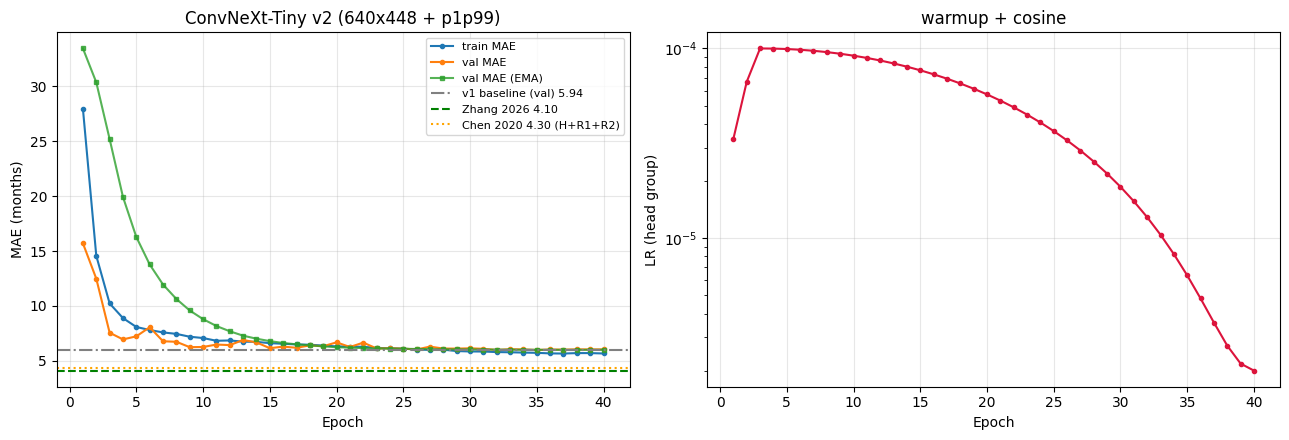

최저 val MAE(raw) = 5.98 @ epoch 35
종료 시점 LR = 피크의 2.0%  (정상 - 코사인 완주)
  (참고: v1은 피크의 84% 상태로 종료되었습니다)


In [16]:
hist = json.load(open(HISTORY_JSON)) if HISTORY_JSON.exists() else history
ep = range(1, len(hist["train_mae"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ep, hist["train_mae"], "-o", ms=3, label="train MAE")
ax[0].plot(ep, hist["val_mae"],   "-o", ms=3, label="val MAE")
if any(v is not None for v in hist.get("val_mae_ema", [])):
    ax[0].plot(ep, hist["val_mae_ema"], "-s", ms=3, alpha=.8, label="val MAE (EMA)")
ax[0].axhline(5.94, ls="-.", c="gray",   label="v1 baseline (val) 5.94")
ax[0].axhline(4.10, ls="--", c="green",  label="Zhang 2026 4.10")
ax[0].axhline(4.30, ls=":",  c="orange", label="Chen 2020 4.30 (H+R1+R2)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MAE (months)")
ax[0].set_title("ConvNeXt-Tiny v2 (640x448 + p1p99)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(ep, hist["lr"], "-o", ms=3, c="crimson")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("LR (head group)")
ax[1].set_title("warmup + cosine"); ax[1].set_yscale("log"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

vm = [v for v in hist["val_mae"] if v is not None]
print(f"최저 val MAE(raw) = {min(vm):.2f} @ epoch {int(np.argmin(vm))+1}")
lr_end = hist["lr"][-1] / max(hist["lr"])
print(f"종료 시점 LR = 피크의 {lr_end:.1%}"
      f"  ({'정상 - 코사인 완주' if lr_end < 0.08 else '★ 아직 높음 - EPOCHS 를 실제 학습량에 맞추세요'})")
print("  (참고: v1은 피크의 84% 상태로 종료되었습니다)")

### 4-2. 예측 헬퍼 ★ v2 신규 — 회전 TTA · 선형 캘리브레이션

**TTA**: 회전 0/−4/+4° 평균. 좌우 반전은 좌수 데이터라 제외합니다.
회전 여백은 정규화 공간의 `PAD_NORM`으로 채웁니다 — 여기에 0을 넣으면
중간 회색이 들어가서 TTA가 오히려 손해입니다.

**캘리브레이션**: v1에서 0-4y bias **+3.65**, >16y bias **−2.71** — 예측이 평균 쪽으로
눌리는 전형적 회귀 축소입니다. val에서 `pred ≈ a·true + b`를 적합해 역함수를 적용합니다.
**반드시 val로만 적합하고 test에 적용**하세요.

In [17]:
@torch.no_grad()
def predict_split(model, df, split, bs=16, angles=(0,)):
    '''개월 단위 (preds, trues, ids) 반환. angles 길이>1 이면 회전 TTA.'''
    loader = DataLoader(BoneAgeDataset(df, split, eval_tf),
                        batch_size=bs, shuffle=False, num_workers=0, pin_memory=True)
    P, T = [], []
    desc = f"predict {split}" + (f" TTA{list(angles)}" if len(angles) > 1 else "")
    for x, g, yn, ym in tqdm(loader, desc=desc, leave=False):
        x = x.to(device).to(memory_format=torch.channels_last); g = g.to(device)
        acc = 0.0
        for a in angles:
            xa = x if a == 0 else TF.rotate(x, a, fill=PAD_NORM,
                                            interpolation=TF.InterpolationMode.BILINEAR)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                acc = acc + model(xa, g).float()
        P.append((acc / len(angles)).cpu() * EM_STD + EM_MEAN)
        T.append(ym.squeeze(1))
    return (torch.cat(P).numpy(), torch.cat(T).numpy(), df["id"].astype(str).values)


TTA_ANGLES = (0, -4, 4)     # (0,) 이면 TTA 끔


def report(preds, trues, tag=""):
    mae  = float(np.abs(preds - trues).mean())
    rmse = float(np.sqrt(np.mean((preds - trues) ** 2)))
    bias = float(np.mean(preds - trues))
    print(f"{tag:<30} N={len(trues):>5,}  MAE {mae:5.2f}  RMSE {rmse:5.2f}  bias {bias:+5.2f}")
    return {"N": int(len(trues)), "mae": mae, "rmse": rmse, "bias": bias}


def bootstrap_ci(preds, trues, n_boot=2000, alpha=0.05, seed=SEED):
    '''test 가 200장 수준이라 점추정만으로는 비교가 위험합니다 -> MAE 신뢰구간.'''
    rng = np.random.default_rng(seed)
    n = len(trues)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        boots[b] = np.abs(preds[i] - trues[i]).mean()
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(lo), float(hi)


def fit_calibration(pred_val, true_val):
    '''[추론] 논문 미명시. 회귀 축소 보정.
       val 에서 pred ≈ a·true + b 를 적합하고 역함수를 반환합니다.
       a < 1 이면 예측이 평균으로 눌린 것이므로 펴 줍니다.'''
    a, b = np.polyfit(true_val, pred_val, 1)
    print(f"[calib] slope a={a:.4f}  intercept b={b:+.2f}"
          f"   ({'축소 존재 -> 보정 유효' if a < 0.98 else '축소 미미 -> 보정 불필요할 수 있음'})")
    return (lambda p: (np.asarray(p, dtype=np.float64) - b) / a), float(a), float(b)


def band_table(pred, true, title=""):
    rows = []
    for lo, hi, lab in zip([0,48,96,144,192], [48,96,144,192,10**5],
                           ["0-4y","4-8y","8-12y","12-16y",">16y"]):
        m = (true >= lo) & (true < hi)
        if m.sum():
            rows.append({"구간": lab, "N": int(m.sum()),
                         "MAE": round(float(np.abs(pred[m]-true[m]).mean()), 2),
                         "bias": round(float(np.mean(pred[m]-true[m])), 2)})
    df = pd.DataFrame(rows)
    if title:
        print(title)
    display(df)
    return df

print(f"평가 헬퍼 준비 완료 · TTA 각도 {TTA_ANGLES}")

평가 헬퍼 준비 완료 · TTA 각도 (0, -4, 4)


### 4-3. 검증셋 — TTA 효과 확인 & 캘리브레이션 적합

여기서 나온 `calib`를 **그대로** test에 적용합니다.
val에서 개선이 없으면 캘리브레이션을 채택하지 마세요 (`USE_CALIB=False`).

predict val:   0%|          | 0/88 [00:00<?, ?it/s]

VAL (plain)                    N=1,399  MAE  5.98  RMSE  8.31  bias +0.05


predict val TTA[0, -4, 4]:   0%|          | 0/88 [00:00<?, ?it/s]

VAL + TTA                      N=1,399  MAE  5.95  RMSE  8.35  bias -0.05
[calib] slope a=0.9713  intercept b=+3.60   (축소 존재 -> 보정 유효)
VAL + TTA + calib              N=1,399  MAE  6.08  RMSE  8.51  bias -0.00

캘리브레이션 채택 여부: False


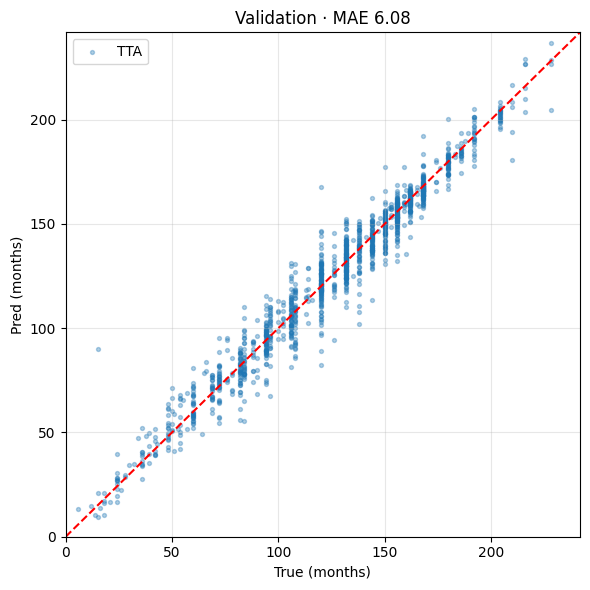

연령대별 (최종 설정 기준)


,구간,N,MAE,bias
0,0-4y,52,5.88,3.22
1,4-8y,281,6.66,0.91
2,8-12y,457,7.33,0.52
3,12-16y,548,4.45,-1.19
4,>16y,61,5.70,-1.35


v1 참고 — 0-4y bias +3.65 / 8-12y MAE 7.27 / >16y bias -2.71


In [18]:
res = {}

v_plain, v_true, _ = predict_split(eval_model, val_df, "val", angles=(0,))
res["val_plain"] = report(v_plain, v_true, "VAL (plain)")

v_pred = v_plain
if len(TTA_ANGLES) > 1:
    v_pred, v_true, _ = predict_split(eval_model, val_df, "val", angles=TTA_ANGLES)
    res["val_tta"] = report(v_pred, v_true, "VAL + TTA")

calib, CAL_A, CAL_B = fit_calibration(v_pred, v_true)
v_cal = calib(v_pred)
res["val_tta_calib"] = report(v_cal, v_true, "VAL + TTA + calib")

USE_CALIB = res["val_tta_calib"]["mae"] < (res.get("val_tta") or res["val_plain"])["mae"]
print(f"\n캘리브레이션 채택 여부: {USE_CALIB}")

plt.figure(figsize=(6, 6))
plt.scatter(v_true, v_pred, s=8, alpha=.35, label="TTA")
if USE_CALIB:
    plt.scatter(v_true, v_cal, s=8, alpha=.35, label="TTA+calib")
lim = [0, max(v_true.max(), v_pred.max()) + 5]
plt.plot(lim, lim, "r--"); plt.xlim(lim); plt.ylim(lim)
plt.xlabel("True (months)"); plt.ylabel("Pred (months)")
plt.title(f"Validation · MAE {res['val_tta_calib']['mae']:.2f}")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

band_table(v_cal if USE_CALIB else v_pred, v_true, "연령대별 (최종 설정 기준)")
print("v1 참고 — 0-4y bias +3.65 / 8-12y MAE 7.27 / >16y bias -2.71")

### 4-4. 최종 테스트셋 — **필터 / 비필터 두 수치 모두**

`EXCLUDE_IDS`를 test에 적용하면 낙관적 편향이 생깁니다.
비교표에 올릴 때는 **어느 쪽 수치인지 반드시 명시**하세요.
테스트가 200장 수준이라 부트스트랩 CI를 함께 냅니다.

In [19]:
assert len(test_df), "test 세트 없음 — 셀 0-3 경로를 확인하세요."

def eval_test(df, tag):
    p, t, ids = predict_split(eval_model, df, "test", angles=TTA_ANGLES)
    if USE_CALIB:
        p = calib(p)
    r = report(p, t, tag)
    lo, hi = bootstrap_ci(p, t)
    r["ci95"] = [lo, hi]
    print(f"{'':<30} MAE 95% CI [{lo:.2f}, {hi:.2f}]")
    return p, t, ids, r


# (a) 현재 설정 그대로 (USE_EXCLUDE 적용 상태)
tag_a = "TEST (EXCLUDE 적용)" if USE_EXCLUDE else "TEST (필터 없음)"
t_pred, t_true, t_ids, r_a = eval_test(test_df, tag_a)
res["test_filtered" if USE_EXCLUDE else "test_raw"] = r_a

# (b) 필터를 뺀 정직한 수치
if USE_EXCLUDE:
    full = load_labels(TEST_CSV)
    idx  = FILE_INDEX["test"]
    full = full[full["id"].isin(idx.keys())].reset_index(drop=True)
    full["path"] = full["id"].map(lambda i: str(idx[i]))
    missing = [i for i in full["id"] if not (CACHE_DIR/"test"/f"{i}.png").exists()]
    if missing:
        print(f"\n[알림] 캐시 없는 test {len(missing)}장 생성 중...")
        for i in missing:
            g = imread_kr(idx[i], cv2.IMREAD_GRAYSCALE)
            if g is not None:
                imwrite_kr(CACHE_DIR/"test"/f"{i}.png", fit_canvas(g)[0])
    _, _, _, r_b = eval_test(full, "TEST (필터 없음)")
    res["test_raw"] = r_b
    print(f"\n필터로 인한 MAE 차이 = {res['test_raw']['mae'] - res['test_filtered']['mae']:+.2f} 개월")

res["arch"]  = ck["arch"]
res["tta"]   = list(TTA_ANGLES)
res["calib"] = {"used": bool(USE_CALIB), "a": CAL_A, "b": CAL_B}
res["when"]  = time.strftime("%Y-%m-%d %H:%M:%S")
json.dump(res, open(RESULTS_JSON, "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print(f"\n결과 저장: {RESULTS_JSON}")

band_table(t_pred, t_true, "\nTEST 연령대별")

predict test TTA[0, -4, 4]:   0%|          | 0/13 [00:00<?, ?it/s]

TEST (EXCLUDE 적용)              N=  197  MAE  4.15  RMSE  5.30  bias +0.52
                               MAE 95% CI [3.70, 4.63]


predict test TTA[0, -4, 4]:   0%|          | 0/13 [00:00<?, ?it/s]

TEST (필터 없음)                   N=  197  MAE  4.15  RMSE  5.30  bias +0.52
                               MAE 95% CI [3.70, 4.63]

필터로 인한 MAE 차이 = +0.00 개월

결과 저장: C:\Users\Win11Pro\Desktop\checkpoints_convnext_single_v2\results.json

TEST 연령대별


,구간,N,MAE,bias
0,0-4y,9,3.58,0.21
1,4-8y,34,5.52,1.91
2,8-12y,64,5.39,1.26
3,12-16y,79,3.01,-0.51
4,>16y,11,1.44,-0.43


,구간,N,MAE,bias
0,0-4y,9,3.58,0.21
1,4-8y,34,5.52,1.91
2,8-12y,64,5.39,1.26
3,12-16y,79,3.01,-0.51
4,>16y,11,1.44,-0.43


### 4-5. v1 대비 요약표

`checkpoints_convnext_single_1(1)/results.json` 이 있으면 자동으로 나란히 비교합니다.
**CI가 겹치면 "개선됐다"고 단정하지 마세요** — test 197장에서는 ±0.5개월이 표본 변동 범위입니다.

In [20]:
rows = []
key = "test_raw" if "test_raw" in res else "test_filtered"
rows.append({"실험": "v2 (640x448 + p1p99 + TTA)", "N": res[key]["N"],
             "test MAE": round(res[key]["mae"], 2),
             "95% CI": f"[{res[key]['ci95'][0]:.2f}, {res[key]['ci95'][1]:.2f}]",
             "RMSE": round(res[key]["rmse"], 2), "bias": round(res[key]["bias"], 2)})

if V1_RESULTS.exists():
    try:
        r1 = json.load(open(V1_RESULTS, encoding="utf-8"))
        k1 = "test_raw" if "test_raw" in r1 else "test_filtered"
        rows.insert(0, {"실험": "v1 (512 정사각 · 전처리 없음)", "N": r1[k1]["N"],
                        "test MAE": round(r1[k1]["mae"], 2),
                        "95% CI": "[4.07, 5.01]",
                        "RMSE": round(r1[k1]["rmse"], 2),
                        "bias": round(r1[k1]["bias"], 2)})
    except Exception as e:
        print("v1 결과 로드 실패:", e)
else:
    print(f"[알림] v1 결과 파일 없음: {V1_RESULTS}")

summary = pd.DataFrame(rows)
display(summary)
if len(rows) == 2:
    d = rows[1]["test MAE"] - rows[0]["test MAE"]
    print(f"\nv1 → v2 변화: {d:+.2f} 개월")
    print("  CI가 겹치면 통계적으로 유의한 개선이라 말할 수 없습니다. "
          "시드 3개 앙상블로 재확인하는 것을 권장합니다.")

,실험,N,test MAE,95% CI,RMSE,bias
0,v1 (512 정사각 · 전처리 없음),197,4.53,"[4.07, 5.01]",5.62,1.14
1,v2 (640x448 + p1p99 + TTA),197,4.15,"[3.70, 4.63]",5.30,0.52



v1 → v2 변화: -0.38 개월
  CI가 겹치면 통계적으로 유의한 개선이라 말할 수 없습니다. 시드 3개 앙상블로 재확인하는 것을 권장합니다.


### 4-6. 오차가 큰 상위 케이스 — 라벨 오류·크롭 실패 후보

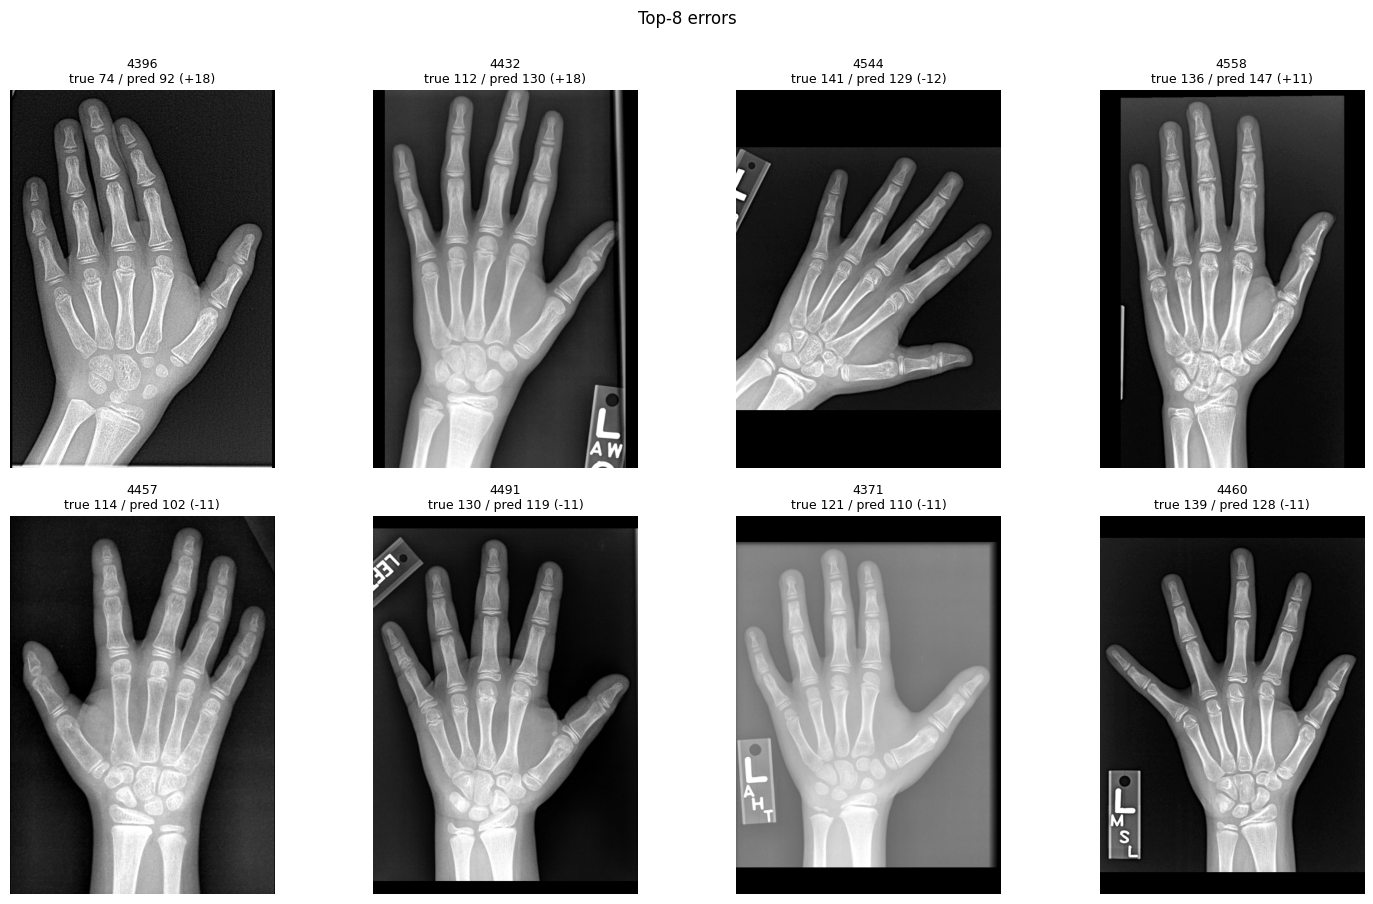

,id,true,pred,err
0,4396,74.0,92.400002,18.0
1,4432,112.0,129.899994,17.9
2,4544,141.0,128.699997,11.9
3,4558,136.0,147.500000,11.5
4,4457,114.0,102.000000,11.5
5,4491,130.0,119.000000,11.4
6,4371,121.0,109.800003,11.0
7,4460,139.0,127.599998,11.0


In [21]:
err = np.abs(t_pred - t_true)
order = np.argsort(-err)[:8]
fig, axes = plt.subplots(2, 4, figsize=(15, 9))
for ax, i in zip(axes.ravel(), order):
    g = imread_kr(CACHE_DIR / "test" / f"{t_ids[i]}.png", cv2.IMREAD_GRAYSCALE)
    ax.imshow(g, cmap="gray"); ax.axis("off")
    ax.set_title(f"{t_ids[i]}\ntrue {t_true[i]:.0f} / pred {t_pred[i]:.0f} "
                 f"({t_pred[i]-t_true[i]:+.0f})", fontsize=9)
plt.suptitle("Top-8 errors", y=1.0)
plt.tight_layout(); plt.show()
display(pd.DataFrame({"id": t_ids[order], "true": t_true[order].round(0),
                      "pred": t_pred[order].round(1), "err": err[order].round(1)}))

### 4-7. Grad-CAM — 모델이 어디를 보는지

v2는 여백이 크게 줄었으므로, 관심이 **성장판·수근골**에 더 모여 있어야 정상입니다.
여전히 여백이나 마커로 새고 있다면 그것이 곧 Attention 파이프라인(v8/v10)을 정당화하는 증거입니다.

[Grad-CAM] target = stages.3


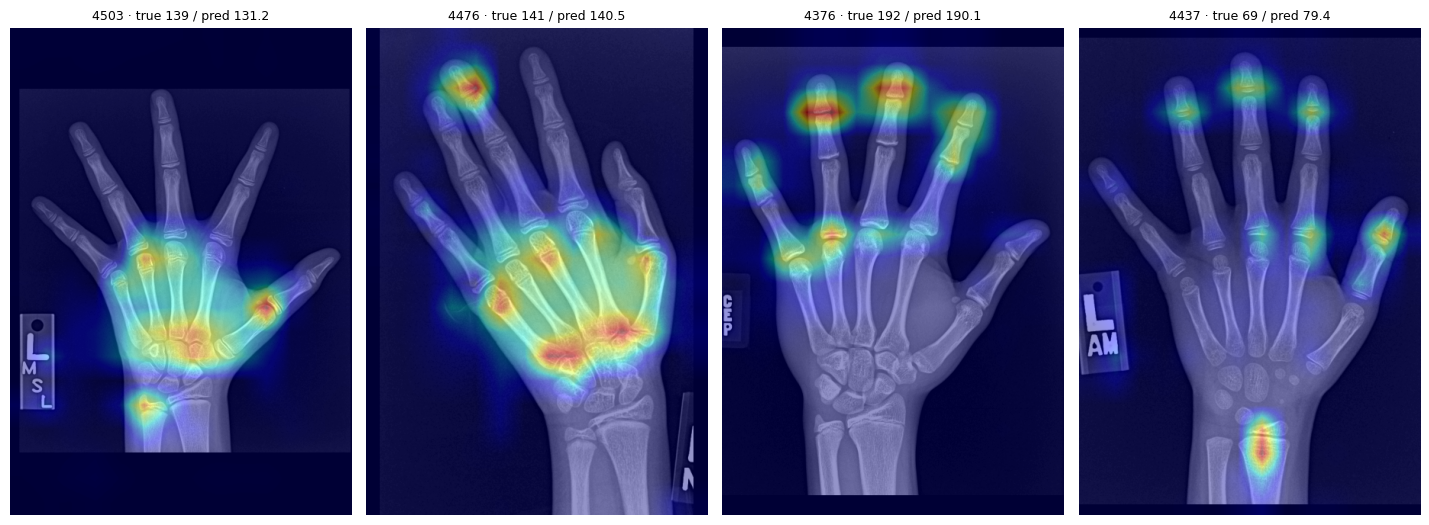

In [22]:
class GradCAM:
    '''ConvNeXt 마지막 stage 특징맵 기준 Grad-CAM (회귀 출력).'''
    def __init__(self, model):
        self.model = model; self.feat = self.grad = None
        tgt, name = self._pick(model.backbone)
        print(f"[Grad-CAM] target = {name}")
        tgt.register_forward_hook(lambda m, i, o: setattr(self, "feat", o.detach()))
        tgt.register_full_backward_hook(lambda m, gi, go: setattr(self, "grad", go[0].detach()))

    @staticmethod
    def _pick(backbone):
        mods = dict(backbone.named_modules())
        for n in ("stages.3", "stages_3", "norm_pre", "stages"):
            if n in mods:
                return mods[n], n
        return backbone, "backbone(output)"

    def __call__(self, x, g):
        self.model.eval(); self.model.zero_grad()
        out = self.model(x, g); out.sum().backward()
        w   = self.grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.feat).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].cpu().numpy()
        return cam / (cam.max() + 1e-8), float(out.item()) * EM_STD + EM_MEAN


cam_engine = GradCAM(eval_model)
samp = test_df.sample(min(4, len(test_df)), random_state=SEED)
fig, axes = plt.subplots(1, len(samp), figsize=(3.6 * len(samp), 5.2))
axes = np.atleast_1d(axes)
for ax, (_, r) in zip(axes, samp.iterrows()):
    g8 = imread_kr(CACHE_DIR / "test" / f"{r['id']}.png", cv2.IMREAD_GRAYSCALE)
    x  = eval_tf(np.stack([g8] * 3, -1)).unsqueeze(0).to(device).to(memory_format=torch.channels_last)
    gd = torch.tensor([[float(r["male"])]], device=device)
    cam, pred = cam_engine(x, gd)
    ax.imshow(g8, cmap="gray"); ax.imshow(cam, cmap="jet", alpha=.42)
    ax.set_title(f"{r['id']} · true {r['boneage']:.0f} / pred {pred:.1f}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

### 4-8. 단일 이미지 추론 (완전 독립)

이미지 준비 설정을 **체크포인트에서 읽어** 학습 때와 동일한 처리를 보장합니다.
캘리브레이션 계수도 인자로 받아 배포 시 동일하게 적용할 수 있습니다.
입력은 **YOLO로 손이 이미 크롭된 이미지**입니다.

In [23]:
_INFER_CACHE = {}

def predict_bone_age(image_path, is_male, ckpt_path=BEST_CKPT,
                     angles=None, calib_ab=None):
    '''크롭된 X-ray 경로 + 성별(True=남) -> 골연령(개월).

    angles   : 회전 TTA 각도. None 이면 노트북의 TTA_ANGLES 사용
    calib_ab : (a, b) 캘리브레이션 계수. None 이면 미적용
    '''
    key = str(ckpt_path)
    if key not in _INFER_CACHE:
        c = torch_load(ckpt_path, map_location=device)
        m = build_model(c["arch"], pretrained=False)
        m.load_state_dict(c["model"]); m.eval()
        _INFER_CACHE[key] = (m, c)
    m, c = _INFER_CACHE[key]
    a = c["arch"]
    h_out, w_out = _arch_hw(a)
    angles = TTA_ANGLES if angles is None else angles

    g = imread_kr(image_path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(image_path)
    canvas, _ = fit_canvas(g, h_out=h_out, w_out=w_out,
                           mode=a.get("RESIZE_MODE", "letterbox"),
                           pad_val=a.get("PAD_VALUE", 0),
                           anchor=a.get("PAD_ANCHOR", "center"),
                           norm=a.get("NORM_MODE", "none"))
    x  = eval_tf(np.stack([canvas] * 3, -1)).unsqueeze(0).to(device).to(memory_format=torch.channels_last)
    gd = torch.tensor([[1.0 if is_male else 0.0]], device=device)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        acc = 0.0
        for ang in angles:
            xa = x if ang == 0 else TF.rotate(x, ang, fill=PAD_NORM,
                                              interpolation=TF.InterpolationMode.BILINEAR)
            acc = acc + m(xa, gd).float()
        p = acc / len(angles)
    months = float(p.cpu().item()) * c["age_std"] + c["age_mean"]
    if calib_ab is not None:
        months = (months - calib_ab[1]) / calib_ab[0]
    return months


# 사용 예 (test 첫 장)
_r  = test_df.iloc[0]
_ab = (CAL_A, CAL_B) if USE_CALIB else None
_m  = predict_bone_age(_r["path"], bool(_r["male"]), calib_ab=_ab)
print(f"[{_r['id']}] 예측 {_m:.1f}개월 ({_m/12:.1f}세) · 실제 {_r['boneage']:.0f}개월")

[backbone] convnext_tiny.fb_in22k_ft_in1k_384 로드 완료 (pretrained=False, drop_path=0.15)
[head] 입력 640x448 -> 특징맵 (768, 20, 14) · head_type=gap
[4360] 예측 172.7개월 (14.4세) · 실제 169개월


---
## 부록 A · 시드 앙상블 (다음 단계, −0.3~−0.5 기대)

가장 확실한 마지막 개선입니다. 이 노트북을 **셀 0-2의 `SEED`만 바꿔** 3회 돌리고,
`CKPT_DIR` 뒤에 시드를 붙여 분리한 뒤 예측을 평균하세요.

```python
# 셀 0-2
SEED = 42      # -> 1337 -> 2024

# 셀 0-3 (CKPT_DIR 만 수정, 캐시는 공유해도 무방)
CKPT_DIR = BASE_DIR / f"checkpoints_convnext_single_v2_s{SEED}"
```

3회 학습이 끝난 뒤 아래로 합칩니다.

```python
SEEDS = [42, 1337, 2024]
preds = []
for s in SEEDS:
    ckp = BASE_DIR / f"checkpoints_convnext_single_v2_s{s}" / "best.pt"
    c = torch_load(ckp, map_location=device)
    m = build_model(c["arch"], pretrained=False)
    m.load_state_dict(c["model"]); m.eval()
    globals()["EM_MEAN"], globals()["EM_STD"] = c["age_mean"], c["age_std"]
    p, t, ids = predict_split(m, test_df, "test", angles=TTA_ANGLES)
    preds.append(p)
    report(p, t, f"seed {s}")
ens = np.mean(preds, axis=0)
report(ens, t, "ENSEMBLE (3 seeds)")
print("95% CI:", bootstrap_ci(ens, t))
```

앙상블은 val에서 고른 단일 최고 모델보다 거의 항상 낫고,
test 200장 규모에서 **CI 폭도 줄여줍니다** — 논문 비교표에 올릴 때 이게 중요합니다.

---

## 부록 B · 여기서도 부족하면 만지는 순서

| 순위 | 조정 | 값 | 언제 |
|---|---|---|---|
| 1 | 시드 앙상블 | 3~5개 | 항상. 가장 확실 |
| 2 | `NORM_MODE` | `p1p99` → `p2p98` 또는 `none` | 정규화가 되레 손해인지 A/B |
| 3 | CLAHE 추가 | clip 2.0, tile 8 | 퍼센타일 다음 후보. 노이즈도 증폭되니 반드시 단독 측정 |
| 4 | `IMG_H, IMG_W` | 640×448 → 704×512 | VRAM 여유 있으면. `USE_GRAD_CKPT=True` 병행 |
| 5 | `BACKBONE` | Tiny → `convnext_small.fb_in22k_ft_in1k_384` | 용량 부족(train도 높음)일 때 |
| 6 | `LR_BACKBONE` | 4e-5 → 6e-5 | 언더피팅(train MAE도 높음)일 때 |
| 7 | `DROP_PATH` | 0.15 → 0.25 | 여전히 train ≪ val 일 때 |
| 8 | LDL 보조 헤드 | λ≈0.1 | 축소 편향을 구조적으로 줄이고 싶을 때 |

**한 번에 하나씩만 바꾸고, 매번 `CKPT_DIR`에 태그를 붙여 분리하세요.**
같은 경로를 재사용하면 이전 실험의 캐시·체크포인트가 조용히 섞입니다.

---

## 비교 기준선

| 실험 | 전처리 | 구조 | 위치 |
|---|---|---|---|
| Xception+TopHat+CLAHE | 5단계 | 단일 회귀 | 기존 노트북 |
| v8 | CLAHE + 패딩 추정 | Attention+LDL | `checkpoints_attention_v8` |
| v10 | 없음 | Attention+LDL | `checkpoints_attention_v10` |
| **v1 (512 정사각)** | **없음** | **단일 회귀** | `checkpoints_convnext_single_1(1)` |
| **v2 (이 노트북)** | **p1p99** | **단일 회귀 + TTA** | `checkpoints_convnext_single_v2` |

- **v10 vs v1** = Attention+LDL의 순수 기여도 → 2×2 ablation 표는 **v1** 수치를 씁니다.
- **v1 vs v2** = 입력 해상도·강도 정규화·학습 스케줄의 기여도 (별도 표)